# RQ3: Can explainable AI improve transparency?

                      Feature  Average SHAP Value
1             Temperature(°C)          300.321389
0                        Hour          240.093669
6     Solar Radiation (MJ/m2)          115.052216
9                     Seasons           54.483708
2                 Humidity(%)           52.111218
11            Functioning Day           50.697563
14                    Weekday           39.166499
7                Rainfall(mm)           36.426591
12                      Month           26.919357
5   Dew point temperature(°C)           24.241644
4            Visibility (10m)            7.169518
10                    Holiday            5.549178
13                        Day            5.158681
3            Wind speed (m/s)            3.656493
8               Snowfall (cm)            2.486328


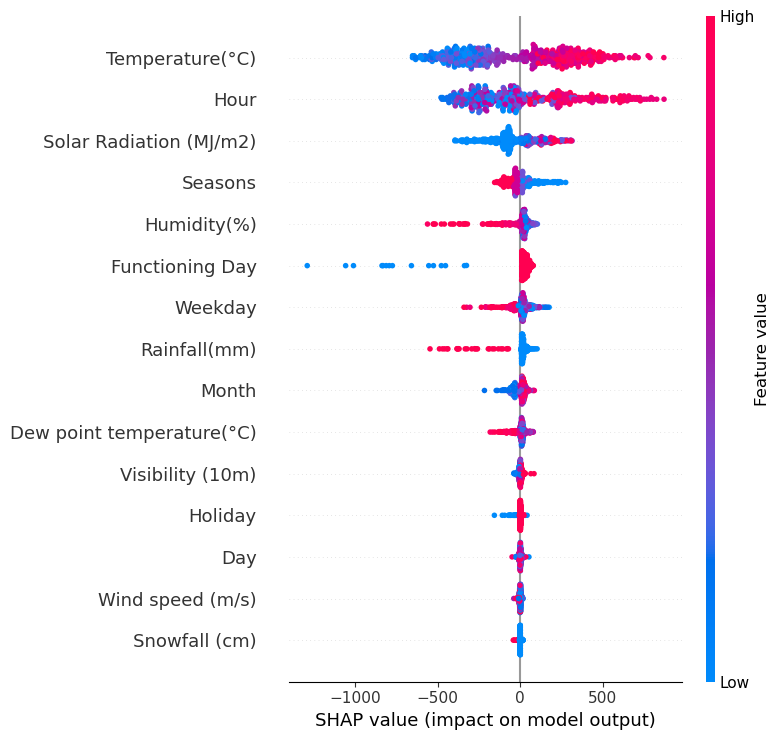

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

import shap

df = pd.read_csv(
    r'C:\Users\Admin\Downloads\SeoulBikeData.csv',
    encoding='latin1'
)

# Preprocessing

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d/%m/%Y'
)

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

encoder = LabelEncoder()

categorical_cols = [
    'Seasons',
    'Holiday',
    'Functioning Day'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Feature Selection

X = df.drop(
    ['Date', 'Rented Bike Count'],
    axis=1
)

y = df['Rented Bike Count']

# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Use Smaller Sample for Faster SHAP

X_sample = X_test[:500]

# SHAP Analysis

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_sample)

# Create SHAP Table

mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': X.columns,
    'Average SHAP Value': mean_shap
})

shap_df = shap_df.sort_values(
    by='Average SHAP Value',
    ascending=False
)

# Save Table

shap_df.to_csv(
    'table3_shap_values.csv',
    index=False
)

print(shap_df)

# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns,
    show=False
)

plt.tight_layout()

# Save Figure

plt.savefig(
    'figure3_shap_summary.pdf',
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>

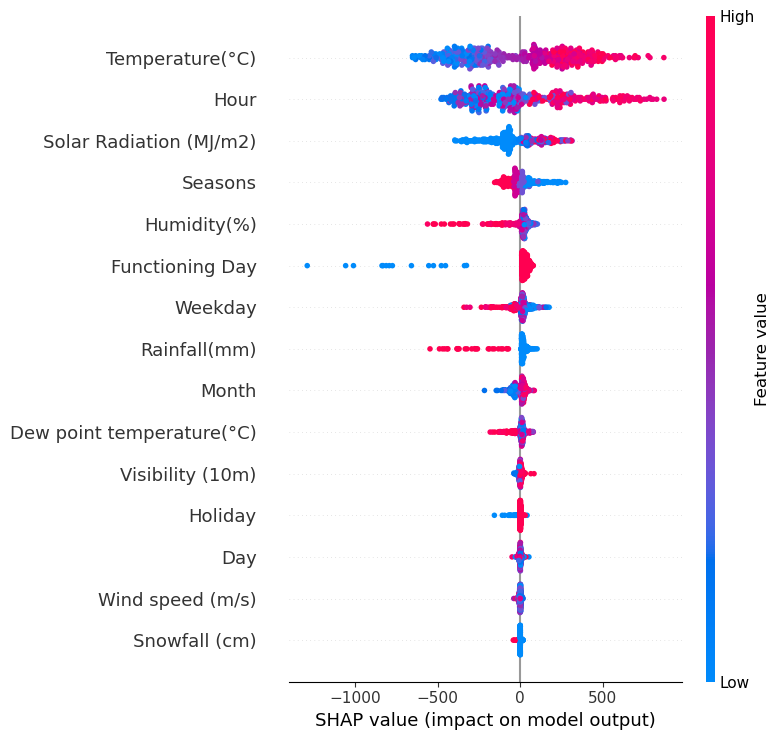

In [5]:

# Generate SHAP summary figure

plt.tight_layout()


plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns,
    show=False
)

plt.tight_layout()

# Save as high-quality PNG
plt.savefig(
    'figure3_shap_summary.png',
    dpi=300,
    bbox_inches='tight'
)

# Save as PDF
plt.savefig(
    'figure3_shap_summary.pdf',
    bbox_inches='tight'
)

plt.show()
